# U.S. Data Scientist Market Analysis (2021) — Analysis Workflow

This notebook reproduces the labor-market analysis behind the dashboard project as a
self-contained, public-safe Python pipeline. The original cleaning was performed in
RapidMiner/Jamovi and the dashboards built in Power BI; here every reported number is
recomputed from the public extract and every figure is regenerated, so the evidence is
reproducible from the repository without proprietary tooling.

**Data:** `data/ds_salary_public.csv` — a feature-level extract derived from a Kaggle
Glassdoor scrape (N = 742 postings, 36 fields). Raw job descriptions, company names,
headquarters, and competitor text are excluded at the source.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data/ds_salary_public.csv")
FIGDIR = Path("docs/figures"); FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.bbox": "tight", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
ACCENT, ACCENT2, NEUTRAL = "#2c6e9c", "#c25a3c", "#9aa7b1"
TOOLS = ["python","spark","aws","excel","sql","sas","keras","pytorch","scikit",
         "tensor","hadoop","tableau","power_bi","flink","mongo","google_analytics"]

## 1. Load the public extract and standardize types

Tool indicators arrive as 0/1 integers. Casting them to boolean lets `mean()` read
directly as *share of postings requiring the tool* rather than a meaningless sum.

In [2]:
df = pd.read_csv(DATA)
df[TOOLS] = df[TOOLS].astype(bool)
df["avg_salary_k"] = pd.to_numeric(df["avg_salary_k"], errors="coerce")
print("shape:", df.shape)
df[["job_title","avg_salary_k","job_state","role_family","degree_required"]].head()

shape: (742, 36)


,job_title,avg_salary_k,job_state,role_family,degree_required
0,Data Scientist,72.0,NM,data scientist,M
1,Healthcare Data Scientist,87.5,MD,data scientist,M
2,Data Scientist,85.0,FL,data scientist,M
3,Data Scientist,76.5,WA,data scientist,na
4,Data Scientist,114.5,NY,data scientist,na


## 2. Normalize noisy role labels into analysis groups

The scraped titles are inconsistent (`data analitics`, `na`,
`Data scientist project manager`). Collapsing them into a small set of role groups
makes salary and skill comparisons legible while retaining every posting.

In [3]:
def role_group(raw):
    r = str(raw).lower()
    if "machine learning" in r: return "ML Engineer"
    if "director" in r or "project man" in r: return "Lead/Director"
    if "data engineer" in r or "modeler" in r: return "Data Engineer"
    if "analyst" in r or "analitics" in r: return "Analyst"
    if "data scientist" in r: return "Data Scientist"
    if "other scientist" in r: return "Other Scientist"
    return "Other/NA"

df["role_grp"] = df["role_family"].apply(role_group)
df["deg"] = df["degree_required"].map({"na":"Not specified","M":"Master's","P":"PhD"})
df["sen"] = df["seniority"].map({"na":"Unspecified","sr":"Senior","jr":"Junior"})
df["role_grp"].value_counts()

role_grp
Data Scientist     313
Other Scientist    143
Data Engineer      124
Analyst            109
ML Engineer         22
Lead/Director       21
Other/NA            10
Name: count, dtype: int64

## 3. Headline statistics

These are the numbers cited in the README, summary, and report. Printing them here keeps
every written claim traceable to a reproducible computation.

In [4]:
sal = df["avg_salary_k"]
print(f"N = {len(df)};  median ${sal.median():.1f}K, mean ${sal.mean():.1f}K, "
      f"range ${sal.min():.1f}K-${sal.max():.1f}K")
role_sal = df.groupby("role_grp")["avg_salary_k"].median().sort_values(ascending=False)
print("\nMedian salary by role group:"); print(role_sal.round(1).to_string())
tool_demand = (df[TOOLS].mean()*100).sort_values(ascending=False)
print("\nTool demand (%):"); print(tool_demand.round(1).to_string())
print("\nMedian salary by degree:"); print(df.groupby("deg")["avg_salary_k"].median().round(1).to_string())
print("\nSalary by seniority:"); print(df.groupby("sen")["avg_salary_k"].agg(["count","median"]).round(1).to_string())

N = 742;  median $97.5K, mean $101.5K, range $15.5K-$254.0K

Median salary by role group:
role_grp
ML Engineer        124.0
Data Scientist     113.5
Data Engineer       99.0
Other/NA            93.5
Other Scientist     81.0
Lead/Director       74.0
Analyst             61.5

Tool demand (%):
python              52.8
excel               52.3
sql                 51.2
aws                 23.7
spark               22.5
tableau             19.9
hadoop              16.7
tensor               9.7
sas                  8.9
power_bi             7.5
scikit               7.3
pytorch              5.3
mongo                5.0
keras                3.9
google_analytics     1.9
flink                1.3

Median salary by degree:
deg
Master's         102.5
Not specified     89.0
PhD              120.0

Salary by seniority:
             count  median
sen                       
Junior           3    56.5
Senior         220   122.0
Unspecified    519    87.5


## 4. Figure 1 — Median salary by role group

The spine of the salary story: an ordered view of how pay scales with role type. ML
Engineer and Data Scientist roles sit well above analyst roles.

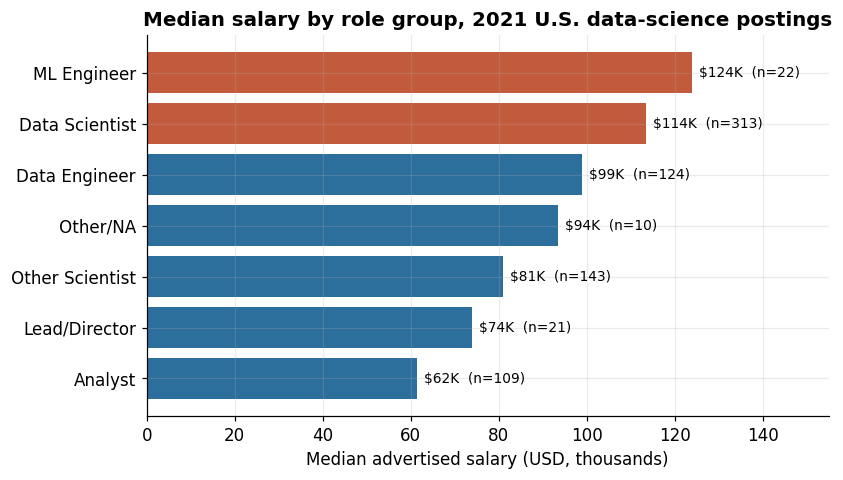

In [5]:
role_counts = df["role_grp"].value_counts()
order = role_sal.index.tolist()
fig, ax = plt.subplots(figsize=(8,4.5))
colors = [ACCENT2 if r in ("ML Engineer","Data Scientist") else ACCENT for r in order]
bars = ax.barh(order, role_sal[order].values, color=colors); ax.invert_yaxis()
for b,r in zip(bars, order):
    ax.text(b.get_width()+1.5, b.get_y()+b.get_height()/2,
            f"${role_sal[r]:.0f}K  (n={role_counts[r]})", va="center", fontsize=9)
ax.set_xlim(0, role_sal.max()*1.25)
ax.set_xlabel("Median advertised salary (USD, thousands)")
ax.set_title("Median salary by role group, 2021 U.S. data-science postings")
fig.savefig(FIGDIR/"fig01-salary-by-role.png"); plt.show()

## 5. Figure 2 — Tool and language demand

A few core tools dominate while a long tail barely registers. Python, Excel, and SQL each
appear in roughly half of postings; Flink and Google Analytics are negligible.

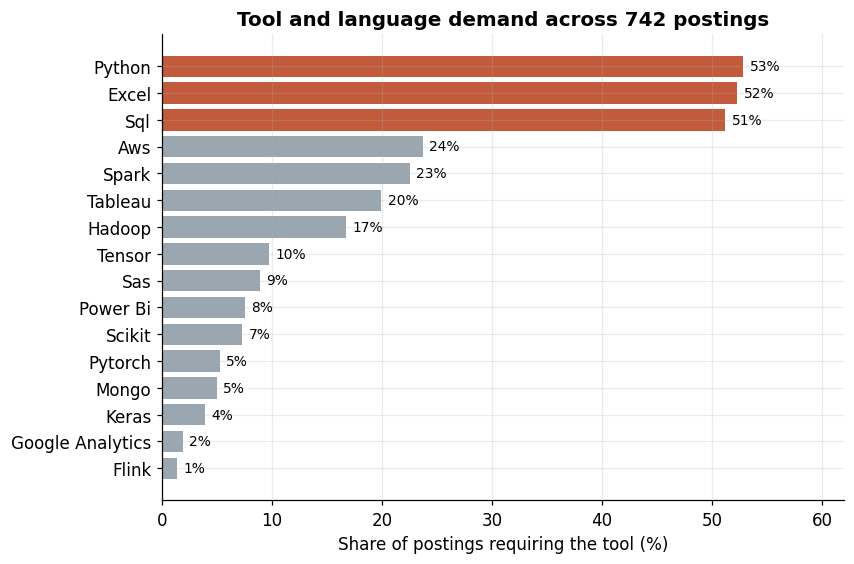

In [6]:
fig, ax = plt.subplots(figsize=(8,5.5))
labels = [t.replace("_"," ").title() for t in tool_demand.index]
cols = [ACCENT2 if v>=50 else NEUTRAL for v in tool_demand.values]
bars = ax.barh(labels, tool_demand.values, color=cols); ax.invert_yaxis()
for b,v in zip(bars, tool_demand.values):
    ax.text(b.get_width()+0.6, b.get_y()+b.get_height()/2, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0,62); ax.set_xlabel("Share of postings requiring the tool (%)")
ax.set_title("Tool and language demand across 742 postings")
fig.savefig(FIGDIR/"fig02-tool-demand.png"); plt.show()

## 6. Figure 3 — Geographic concentration (volume vs. pay)

Bar height encodes posting volume; the line encodes median salary. California leads on both,
but high-volume markets do not all pay alike — NY sits below MA and IL on pay.

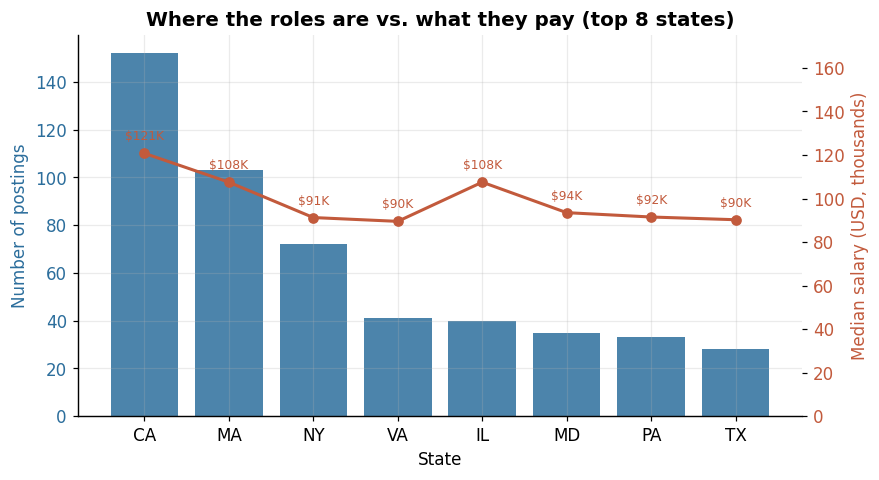

In [7]:
state_counts = df["job_state"].value_counts().head(8)
state_sal = df.groupby("job_state")["avg_salary_k"].median()
top = state_counts.index.tolist(); med = [state_sal[s] for s in top]
fig, ax1 = plt.subplots(figsize=(8.5,4.5))
ax1.bar(top, state_counts.values, color=ACCENT, alpha=0.85)
ax1.set_ylabel("Number of postings", color=ACCENT); ax1.tick_params(axis="y", labelcolor=ACCENT)
ax2 = ax1.twinx(); ax2.plot(top, med, color=ACCENT2, marker="o", linewidth=2)
ax2.set_ylabel("Median salary (USD, thousands)", color=ACCENT2)
ax2.tick_params(axis="y", labelcolor=ACCENT2); ax2.grid(False); ax2.set_ylim(0, max(med)*1.45)
for x,m in zip(top, med): ax2.text(x, m+6, f"${m:.0f}K", ha="center", color=ACCENT2, fontsize=8)
ax1.set_title("Where the roles are vs. what they pay (top 8 states)"); ax1.set_xlabel("State")
fig.savefig(FIGDIR/"fig03-geo-concentration.png"); plt.show()

## 7. Figures 4–5 — Degree and seniority gradients

Box plots show the full salary spread by required degree; the bar chart isolates the senior
pay premium. Junior (n=3) is shown but too small to interpret.

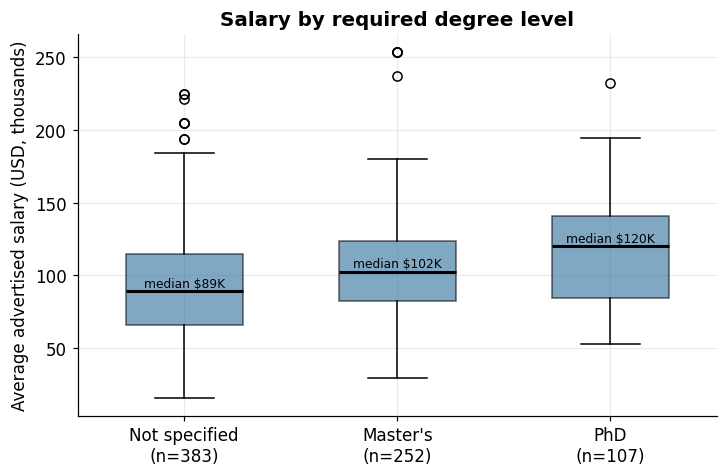

In [8]:
deg_order = ["Not specified","Master's","PhD"]
data_deg = [df.loc[df.deg==d,"avg_salary_k"].dropna().values for d in deg_order]
fig, ax = plt.subplots(figsize=(7.5,4.5))
bp = ax.boxplot(data_deg, patch_artist=True, widths=0.55, medianprops=dict(color="black", linewidth=2))
for p in bp["boxes"]: p.set_facecolor(ACCENT); p.set_alpha(0.6)
ax.set_xticklabels([f"{d}\n(n={len(v)})" for d,v in zip(deg_order,data_deg)])
ax.set_ylabel("Average advertised salary (USD, thousands)"); ax.set_title("Salary by required degree level")
for i,v in enumerate(data_deg,1): ax.text(i, np.median(v)+3, f"median ${np.median(v):.0f}K", ha="center", fontsize=8)
fig.savefig(FIGDIR/"fig04-salary-by-degree.png"); plt.show()

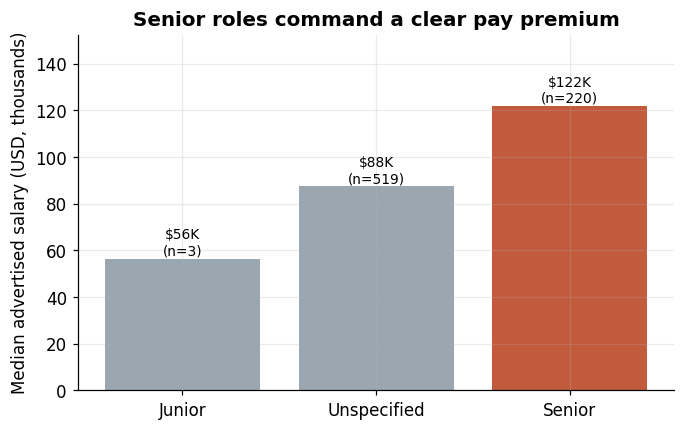

In [9]:
sen_order = ["Junior","Unspecified","Senior"]
sen_med = [df.loc[df.sen==s,"avg_salary_k"].median() for s in sen_order]
sen_n = [int((df.sen==s).sum()) for s in sen_order]
fig, ax = plt.subplots(figsize=(7,4.2))
bars = ax.bar(sen_order, sen_med, color=[NEUTRAL,NEUTRAL,ACCENT2])
for b,m,c in zip(bars,sen_med,sen_n):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.5, f"${m:.0f}K\n(n={c})", ha="center", fontsize=9)
ax.set_ylim(0, max(sen_med)*1.25); ax.set_ylabel("Median advertised salary (USD, thousands)")
ax.set_title("Senior roles command a clear pay premium")
fig.savefig(FIGDIR/"fig05-salary-by-seniority.png"); plt.show()

## 8. Figure 6 — Tool demand by role group

A role x tool matrix exposes distinct skill bundles: analysts cluster on Excel/SQL,
scientists and ML engineers on Python plus deep-learning libraries (TensorFlow, scikit-learn,
PyTorch) that are essentially absent from analyst postings.

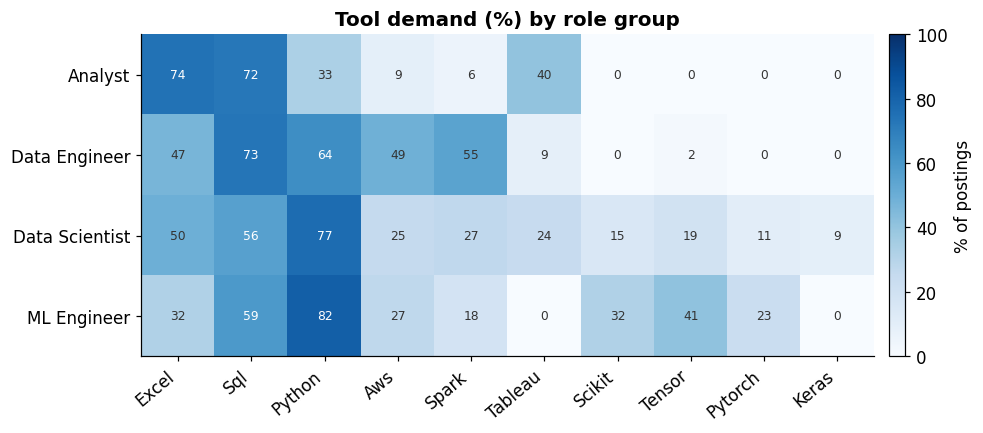

In [10]:
heat_roles = ["Analyst","Data Engineer","Data Scientist","ML Engineer"]
heat_tools = ["excel","sql","python","aws","spark","tableau","scikit","tensor","pytorch","keras"]
mat = np.array([[df.loc[df.role_grp==r, t].mean()*100 for t in heat_tools] for r in heat_roles])
fig, ax = plt.subplots(figsize=(9,3.8))
im = ax.imshow(mat, cmap="Blues", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(heat_tools))); ax.set_xticklabels([t.replace("_"," ").title() for t in heat_tools], rotation=40, ha="right")
ax.set_yticks(range(len(heat_roles))); ax.set_yticklabels(heat_roles)
for i in range(len(heat_roles)):
    for j in range(len(heat_tools)):
        ax.text(j,i,f"{mat[i,j]:.0f}", ha="center", va="center", color="white" if mat[i,j]>55 else "#333", fontsize=8)
ax.set_title("Tool demand (%) by role group"); ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="% of postings")
fig.savefig(FIGDIR/"fig06-tool-by-role.png"); plt.show()

## 9. Figure 7 — Employer profile

Who is hiring: ownership split and the leading sectors. Private employers dominate, and
hiring concentrates in Information Technology, Biotech/Pharma, and Business Services.

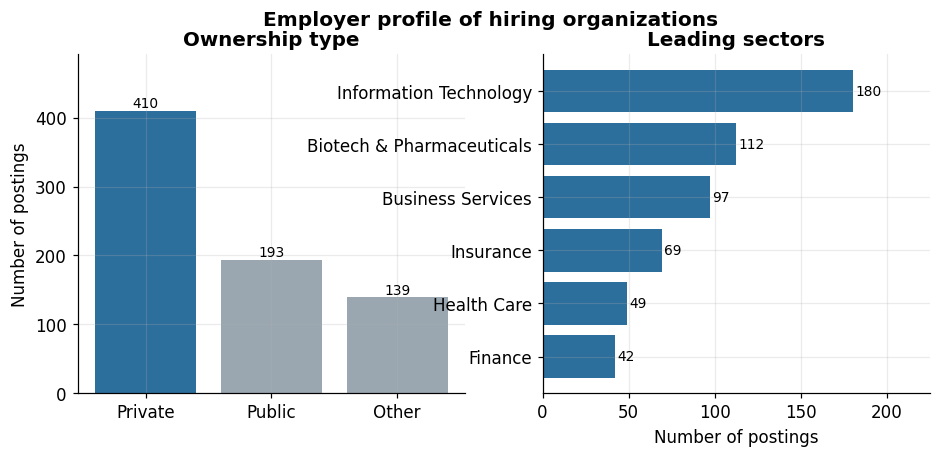

In [11]:
own = df["ownership_type"].apply(lambda x: "Private" if "Private" in str(x) else ("Public" if "Public" in str(x) else "Other"))
fig,(axa,axb)=plt.subplots(1,2,figsize=(10,4))
oc = own.value_counts()[["Private","Public","Other"]]
axa.bar(oc.index, oc.values, color=[ACCENT,NEUTRAL,NEUTRAL])
for i,v in enumerate(oc.values): axa.text(i, v+5, str(v), ha="center", fontsize=9)
axa.set_title("Ownership type"); axa.set_ylabel("Number of postings"); axa.set_ylim(0, oc.max()*1.2)
sec = df["sector"].value_counts().head(6)[::-1]
axb.barh(sec.index, sec.values, color=ACCENT)
for i,v in enumerate(sec.values): axb.text(v+1.5, i, str(v), va="center", fontsize=9)
axb.set_title("Leading sectors"); axb.set_xlabel("Number of postings"); axb.set_xlim(0, sec.max()*1.25)
fig.suptitle("Employer profile of hiring organizations", fontweight="bold")
fig.savefig(FIGDIR/"fig07-employer-profile.png"); plt.show()

## 10. Takeaways

- **Pay scales with role and seniority.** ML Engineer (median \$124K) and Data Scientist
  (\$114K) lead; Analyst roles trail at \$62K. Senior postings (\$122K) pay a clear premium
  over unspecified-level roles (\$88K), and PhD-required roles (\$120K) over those with no
  stated degree (\$89K).
- **A small core stack dominates.** Python (52.8%), Excel (52.3%), and SQL (51.2%) anchor the
  market; deep-learning libraries concentrate in scientist/ML roles.
- **Demand clusters geographically.** California, Massachusetts, and New York lead on volume,
  with California highest on pay.

These are directional signals from a 2021 public posting snapshot, not authoritative
compensation benchmarks.